# RQ1.1 and RQ1.2 — temporal behavior of the token embeddings

Worked example: **FID 188 (clear cut bare soil), tile 0, token (3, 6), cloud filter v3**.

Chosen because it is covered by a single tile, so tile and polygon coincide and the block
artifact of Section 4.1.1 does not apply; because it has dates in all three windows
(optical 4/3/3); and because it belongs to the test split of the 346 polygons on which the
quantitative analysis is evaluated, so the example is not drawn from outside the evaluated
set.

The three readings of the methodology, each for the optical, SAR and joint modes:

1. **Similarity between dates** — the $T \times T$ cosine similarity matrix
2. **Most variable dimension** — the single embedding coordinate that responds most
3. **Trajectory in the reduced space** — PC1 to PC3 on axes fitted once on a reference image

Then, for RQ1.2, two figures on the cloud filter: the images each filter admits, and the
trajectory each filter would deliver.

Every figure is exported to PDF with the same publication settings as
`croma_fid_embeddings_charlotte.ipynb`.

In [12]:
# ── 0. working directory ────────────────────────────────────────────────
# All paths in time_series_pipeline are relative (embeddings/, data/data_csv/,
# data/data_shp/), so the notebook MUST run from the repository root. Without
# this the globs return empty and every function skips silently.
import os

REPO = os.path.expanduser("~/tropical_forest_disturbance")
os.chdir(REPO)
for d in ("embeddings", "data/data_csv", "data/data_shp"):
    assert os.path.isdir(d), f"{d} not found — wrong cwd: {os.getcwd()}"
print("cwd:", os.getcwd())

cwd: /share/castor/home/e2406749/tropical_forest_disturbance


In [13]:
# ── 1. publication figure config ────────────────────────────────────────
# Same settings as croma_fid_embeddings_charlotte.ipynb, cell 50.
from pathlib import Path
import matplotlib.pyplot as plt

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "no-latex"])
except (ImportError, OSError):
    print("scienceplots not available, falling back to the default style")

TEXT_W = 160 / 25.4           # 6.30 in, text width of the document
FIGDIR = Path("qualitative/results/figures_rq1")  # copy down to the manuscript figures/ afterwards
FIGDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 12, "axes.labelsize": 12, "axes.titlesize": 11,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 10,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "savefig.bbox": "tight",
})
print("figures ->", FIGDIR.resolve())

figures -> /share/castor/home/e2406749/tropical_forest_disturbance/qualitative/results/figures_rq1


In [14]:
# ── 2. capture the figures the pipeline draws ───────────────────────────
# The plotting helpers call plt.show() internally and neither return nor save
# their figures, so plt.show is wrapped to export each one to PDF at the
# document text width before displaying it.
#
# The wrapper keeps a reference to the REAL plt.show on itself, so re-running
# this cell rebinds against the original instead of against the wrapper. Without
# that guard the second run makes the wrapper call itself and it recurses,
# writing one PDF per level until it is interrupted.
#
# time_series_pipeline calls plt.show() ten times and plt.close() never, so if
# the backend does not close on show the figures pile up and every later call
# re-saves all of them. Hence the explicit close at the end.
_orig_show = getattr(plt.show, "_orig_show", plt.show)
_state = {"prefix": "fig", "n": 0}


def set_prefix(prefix):
    """Name the PDFs of everything drawn from here on."""
    _state["prefix"], _state["n"] = prefix, 0


def _fit_width(fig, width=TEXT_W):
    """Scale to the text width, keeping the aspect ratio."""
    w, h = fig.get_size_inches()
    fig.set_size_inches(width, h * width / w)


def _save_and_show(*args, **kwargs):
    nums = plt.get_fignums()
    for num in nums:
        fig = plt.figure(num)
        _state["n"] += 1
        out = FIGDIR / f"{_state['prefix']}_{_state['n']:02d}.pdf"
        _fit_width(fig)
        fig.savefig(out)
        print(f"    saved {out.name}")
    _orig_show(*args, **kwargs)
    for num in nums:
        plt.close(num)


_save_and_show._orig_show = _orig_show
plt.show = _save_and_show


def clear_figures():
    """Wipe FIGDIR. Run before a clean pass so old PDFs do not linger."""
    n = 0
    for p in FIGDIR.glob("*.pdf"):
        p.unlink(); n += 1
    print(f"removed {n} pdf")


print("plt.show patched")

plt.show patched


In [15]:
# ── 3. the worked example ───────────────────────────────────────────────
import time_series_pipeline as tsp
from time_series_pipeline import (CSV_TEMPLATE, _create_embeddings,
                                  _allowed_ids_for_fid, _cosine_sim_plot,
                                  _most_variable_dim, _pca_first_image,
                                  _pick_random_token, _event_date,
                                  _paths_for, _by_win)
from collections import Counter

FID, TILE, VERSION = 188, 0, "v3"
TOK_R, TOK_C = 3, 6          # frozen: drawn once at random with SEED below
SEED = 42
MODES = ("optical", "sar", "joint")

# _VERSION is a module global that appears in every plot title. The helpers
# below do not set it (only complete_analysis does), so set it here.
tsp._VERSION = VERSION

csv_path = CSV_TEMPLATE.format(version=VERSION)
_create_embeddings(FID, csv_path, 7)          # skips whatever already exists
allowed = _allowed_ids_for_fid(csv_path, FID)
S2, S1 = allowed["s2"], allowed["s1"]

print(f"fid {FID} tile {TILE} — {VERSION}")
print(f"  event date: {_event_date(FID)}")
for mode in MODES:
    c = Counter(_by_win(p) for p in _paths_for(FID, TILE, mode, S2, S1))
    print(f"  {mode:<8} bef={c['bef']:>3} evt={c['evt']:>3} aft={c['aft']:>3}")

[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_188/aft/20230704T142721_20230704T142729_T20LNR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_188/aft/20230709T142719_20230709T142938_T20LNR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_188/aft/20230719T142719_20230719T142939_T20LNR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_188/bef/20230130T142709_20230130T143158_T20LNR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_188/bef/20230214T142711_20230214T143425_T20LNR
[done] All embeddings already exist in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/s2_l2a/fid_188/bef/20230326T142711_20230326T142710_T20LNR
[done] All embed

removed 12 pdf
  explicit token (3, 6)
    saved rq11_fid188_token_01.pdf


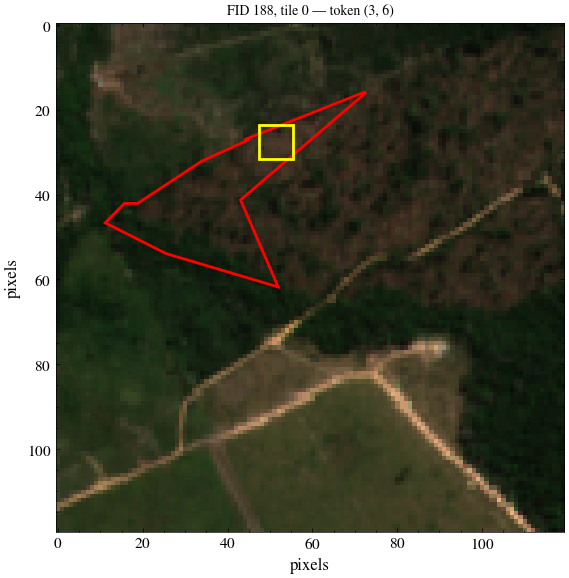

In [16]:
# pick (or show) the token, and see where it falls inside the polygon
#
# Drawn here rather than with _show_explicit_token, which titles the plot in pixel
# coordinates and marks a point. For the manuscript the marker has to be the token
# itself: a square of 8 by 8 pixels, labelled in token coordinates, so the figure
# and the text speak the same language.
import rasterio
import geopandas as gpd
from matplotlib.patches import Polygon as MplPolygon, Rectangle
from time_series_pipeline import _load_polygon, _first_s2_tile

clear_figures()
set_prefix(f"rq11_fid{FID}_token")

if TOK_R is None or TOK_C is None:
    TOK_R, TOK_C, *_ = _pick_random_token(FID, TILE, SEED)
    print(f"  random token -> ({TOK_R}, {TOK_C})   "
          f"# write these into TOK_R / TOK_C above to freeze the figures")
else:
    print(f"  explicit token ({TOK_R}, {TOK_C})")

gdf, poly = _load_polygon(FID)
with rasterio.open(_first_s2_tile(FID, TILE)) as src:
    poly_t = gpd.GeoSeries([poly], crs=gdf.crs).to_crs(src.crs).iloc[0]
    rgb = src.read([4, 3, 2]).transpose(1, 2, 0)
    poly_pix = [~src.transform * (x, y) for x, y in zip(*poly_t.exterior.xy)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb / 3000, vmin=0, vmax=1)
ax.add_patch(MplPolygon(poly_pix, fill=False, edgecolor="red", lw=2))
ax.add_patch(Rectangle((TOK_C * 8 - 0.5, TOK_R * 8 - 0.5), 8, 8,
                       fill=False, edgecolor="yellow", lw=2))
ax.set_title(f"FID {FID}, tile {TILE} — token ({TOK_R}, {TOK_C})", fontsize=10)
ax.set_xlabel("pixels")
ax.set_ylabel("pixels")
ax.grid(False)
fig.tight_layout()
plt.show()

## Reading 1 — similarity between dates

One $T \times T$ cosine similarity matrix per mode. Dates whose embeddings are
alike form blocks, so a disturbance should appear as a boundary between blocks at
the event date.

This is the reading that carries the **modality** axis of RQ1.1.

### cosine optical
    saved rq11_fid188_cosine_optical_01.pdf


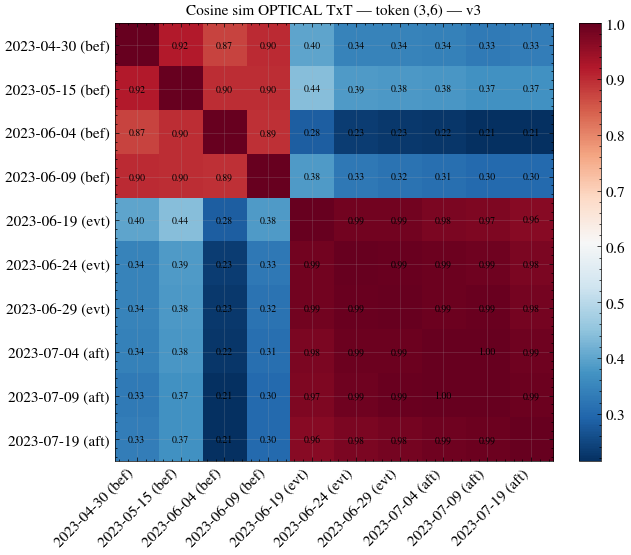

### cosine sar
    saved rq11_fid188_cosine_sar_01.pdf


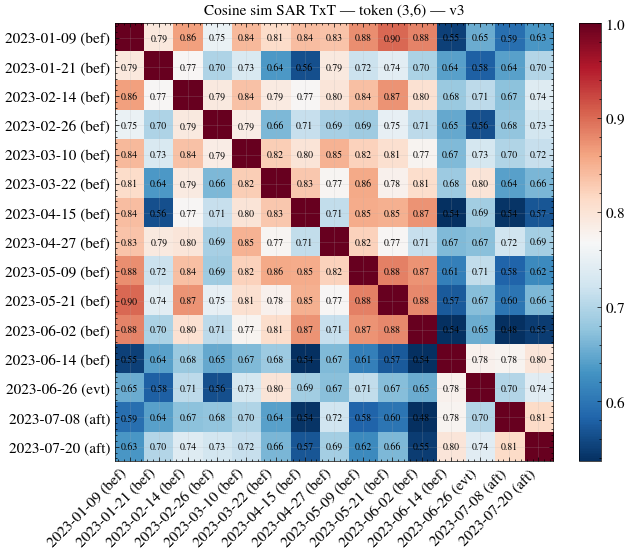

### cosine joint
    saved rq11_fid188_cosine_joint_01.pdf


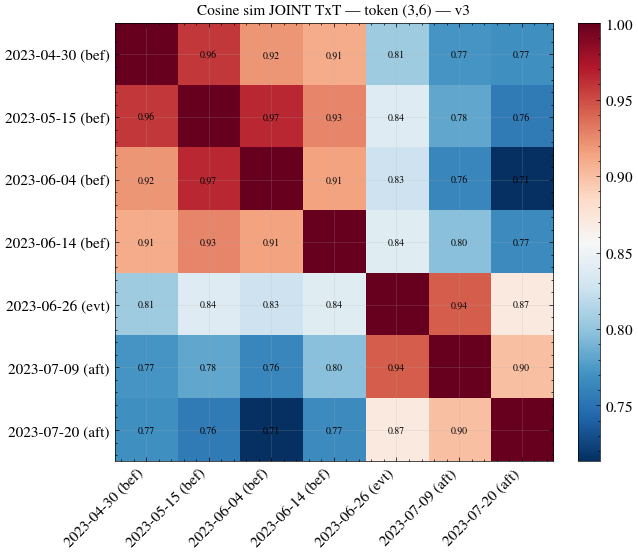

In [17]:
for mode in MODES:
    print(f"### cosine {mode}")
    set_prefix(f"rq11_fid{FID}_cosine_{mode}")
    _cosine_sim_plot(FID, TILE, TOK_R, TOK_C, mode, S2, S1)

## Reading 2 — most variable dimension

The tokens of the tile are averaged at each date, giving an array of dates by 768
dimensions; the dimension with the largest standard deviation across the series
is followed through time.

The dimension selected depends on the tile and on the mode, so these panels are
**not comparable with one another** — the quantity plotted is a different
coordinate in each. One panel is enough for the manuscript; the three are run
here only to see which mode responds.

### most variable dim optical
[optical] cube shape: (10, 15, 15, 768) | unit: token (3,6)
[optical] top dim: 172 (std=1.7374)
[optical] top 5 dims: [172, 414, 752, 738, 211]
[optical] top 5 scores: [1.7374000549316406, 1.6776000261306763, 1.6592999696731567, 1.6229000091552734, 1.5706000328063965]
    saved rq11_fid188_mvd_optical_01.pdf


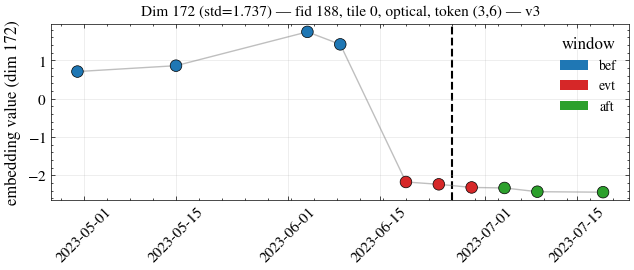

### most variable dim sar
[sar] cube shape: (15, 15, 15, 768) | unit: token (3,6)
[sar] top dim: 447 (std=1.0614)
[sar] top 5 dims: [447, 254, 51, 469, 505]
[sar] top 5 scores: [1.061400055885315, 1.059999942779541, 0.9666000008583069, 0.95169997215271, 0.890999972820282]
    saved rq11_fid188_mvd_sar_01.pdf


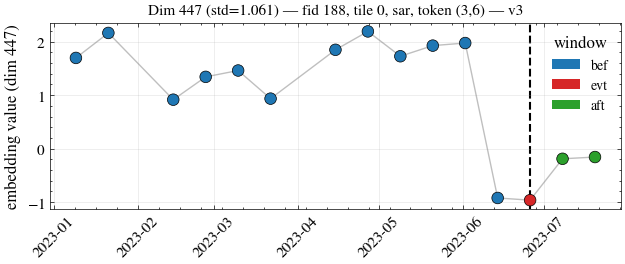

### most variable dim joint
[joint] cube shape: (7, 15, 15, 768) | unit: token (3,6)
[joint] top dim: 274 (std=1.1818)
[joint] top 5 dims: [274, 712, 759, 358, 664]
[joint] top 5 scores: [1.1818000078201294, 1.114799976348877, 0.8428000211715698, 0.7875000238418579, 0.7724000215530396]
    saved rq11_fid188_mvd_joint_01.pdf


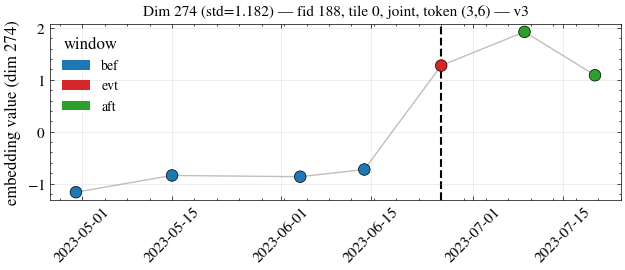

In [18]:
for mode in MODES:
    print(f"### most variable dim {mode}")
    set_prefix(f"rq11_fid{FID}_mvd_{mode}")
    _most_variable_dim(FID, TILE, mode, S2, S1, tok_r=TOK_R, tok_c=TOK_C)

## Reading 3 — trajectory in the reduced space

PCA of three components, fitted once on a single reference image (the earliest
Sentinel-2 date common to the three cloud filters) using its 225 tokens as
samples. The token series is projected onto those fixed axes.

Drawn here rather than with `_pca_first_image`, which places the window and
component legends inside the axes, where they cover the series. One figure per
mode, `rq11_fid188_pca_<mode>_01.pdf`.

The axes are fitted per mode, so PC1 in optical and PC1 in joint are different
axes: only the shape of the trajectory is comparable between modes, never the
values. State this in the caption.

shared PCA x range: (Timestamp('2023-01-04 00:00:00'), Timestamp('2023-07-25 00:00:00'))
### PCA optical
20230430
[optical] 10 dates | EVR=[0.248, 0.089, 0.075]
    saved rq11_fid188_pca_optical_01.pdf


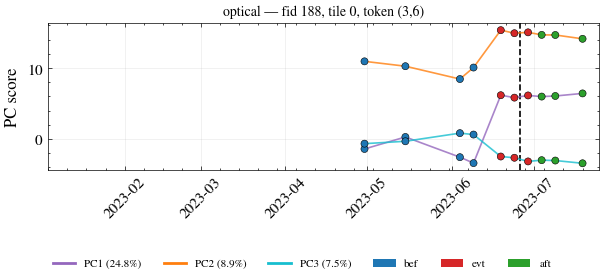

### PCA sar
20230430
[sar] 15 dates | EVR=[0.15, 0.102, 0.081]
    saved rq11_fid188_pca_sar_01.pdf


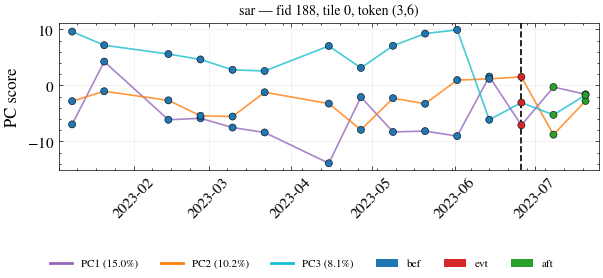

### PCA joint
20230430
[joint] 7 dates | EVR=[0.245, 0.103, 0.068]
    saved rq11_fid188_pca_joint_01.pdf


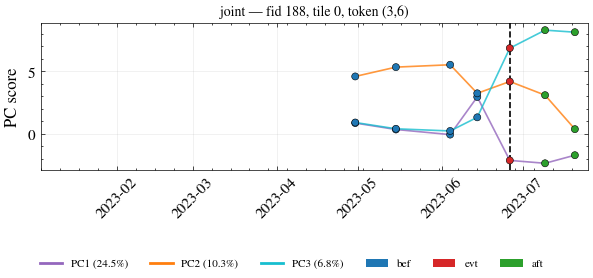

In [19]:
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from time_series_pipeline import WIN_COLORS, _fit_common_base_pca, _by_date_any

PC_COLORS = ["tab:purple", "tab:orange", "tab:cyan"]


def pca_date_range(fid, tile, modes, pad_days=5):
    """Date limits covering every mode, so the PCA panels share one time axis.

    Each mode is observed on its own dates, so an autoscaled axis puts the reference
    date at a different horizontal position in every panel. These limits place it
    identically in all of them. Only the PCA reading uses this: the most variable
    dimension keeps its own axis, since its panels are not read against each other.
    """
    dates = []
    for m in modes:
        dates += [_by_date_any(p)[:8] for p in _paths_for(fid, tile, m, S2, S1)]
    if not dates:
        return None
    d = pd.to_datetime(sorted(dates))
    pad = pd.Timedelta(days=pad_days)
    return d.min() - pad, d.max() + pad


def pca_trajectory(fid, tile, tok_r, tok_c, modality, nc=3, xlim=None):
    """PC1 to PC3 of one token through time, with the legends outside the axes.

    _pca_first_image places both legends inside the plot, where they cover the
    series. Here they go in a single row underneath, so the full vertical range
    stays available to the data.
    """
    base = _fit_common_base_pca(fid, tile, modality, nc)
    paths = _paths_for(fid, tile, modality, S2, S1)
    if base is None or not paths:
        print(f"[{modality}] nothing to plot")
        return
    pca, evr = base[0], base[0].explained_variance_ratio_

    cube = np.stack([np.load(p) for p in paths])
    scores = pca.transform(cube[:, tok_r, tok_c, :])
    dates = pd.to_datetime([_by_date_any(p)[:8] for p in paths])
    colors = [WIN_COLORS[_by_win(p)] for p in paths]
    print(f"[{modality}] {len(paths)} dates | EVR={[round(float(v), 3) for v in evr]}")

    fig, ax = plt.subplots(figsize=(TEXT_W, TEXT_W * 0.40))
    for k in range(nc):
        ax.plot(dates, scores[:, k], "-", color=PC_COLORS[k], alpha=0.8, lw=1.2)
        ax.scatter(dates, scores[:, k], c=colors, s=26,
                   edgecolors="black", linewidths=0.4, zorder=3)

    evt = _event_date(fid)
    if evt is not None:
        ax.axvline(evt, color="black", ls="--", lw=1.2, zorder=0)

    if xlim is not None:
        ax.set_xlim(*xlim)          # shared across modes, see pca_date_range
    ax.set_ylabel("PC score")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.25)
    ax.set_title(f"{modality} — fid {fid}, tile {tile}, token ({tok_r},{tok_c})",
                 fontsize=10)

    handles = [plt.Line2D([0], [0], color=PC_COLORS[k], lw=2,
                          label=f"PC{k+1} ({evr[k]:.1%})") for k in range(nc)]
    handles += [Patch(facecolor=c, label=w) for w, c in WIN_COLORS.items()]
    fig.legend(handles=handles, ncol=6, fontsize=8, loc="lower center",
               bbox_to_anchor=(0.5, -0.16), frameon=False)
    fig.tight_layout()
    plt.show()


PCA_XLIM = pca_date_range(FID, TILE, MODES)
print("shared PCA x range:", PCA_XLIM)

for mode in MODES:
    print(f"### PCA {mode}")
    set_prefix(f"rq11_fid{FID}_pca_{mode}")
    pca_trajectory(FID, TILE, TOK_R, TOK_C, mode, xlim=PCA_XLIM)

## RQ1.2a — the images the strict filters remove

The Sentinel-2 composite of every date any filter admits, in chronological order, coloured by how
many filters keep it. This figure answers **why** a date is removed; the next one answers what
removing it does to the series.

The set is the union of the three filters and not that of Filter 1, since the filters are not nested
in general: Filter 3 is Filter 2 with a dilation and is always contained in it, but Filter 1 and
Filter 2 use different detection algorithms and each admits acquisitions the other rejects.

  F1 F2 F3   10 dates
  F1 F2      1 dates
  F1         3 dates
    saved rq12_rgb_fid188_01.pdf


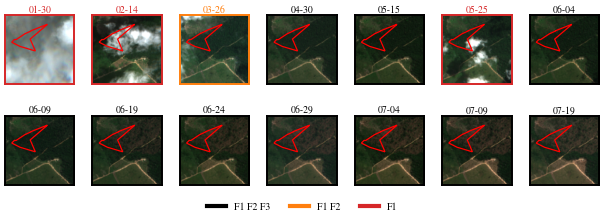

In [20]:
import csv
import rasterio
import geopandas as gpd
from matplotlib.patches import Polygon as MplPolygon
from time_series_pipeline import _load_polygon


def _admitting_filters(fid, versions=("v1", "v2", "v3")):
    """image_id -> set of filters that admit it."""
    out = {}
    for v in versions:
        with open(CSV_TEMPLATE.format(version=v), newline="") as f:
            for r in csv.DictReader(f):
                if int(float(r["fid"])) != fid:
                    continue
                for w in ("bef", "evt", "aft"):
                    for i in (r.get(f"{w}IdsS2") or "").split(","):
                        if i.strip():
                            out.setdefault(i.strip(), set()).add(v)
    return out


def rgb_grid_by_filter(fid, tile, ncols=7, vmax=3000, versions=("v1", "v2", "v3")):
    """S2 composite of every date any filter admits, framed by how many keep it."""
    adm = _admitting_filters(fid, versions)
    s2 = set().union(*(_allowed_ids_for_fid(CSV_TEMPLATE.format(version=v), fid)["s2"]
                       for v in versions))
    s1 = set().union(*(_allowed_ids_for_fid(CSV_TEMPLATE.format(version=v), fid)["s1"]
                       for v in versions))
    paths = _paths_for(fid, tile, "optical", s2, s1)
    if not paths:
        print("nothing to plot")
        return

    # Labelled by the exact set of filters, not by its size: two filters could be
    # {F1,F2} or {F2,F3} in general, and what the reader needs is which one is the
    # permissive one. The colour still comes from the size, so the scale keeps
    # reading black to red as filters drop away.
    def _lab(s):
        return " ".join(f"F{v[-1]}" for v in sorted(s))

    COL = {1: "tab:red", 2: "tab:orange", 3: "black"}
    sets = [frozenset(adm.get(tsp._image_id_of(p), set())) for p in paths]
    cols = [COL[len(s)] for s in sets]
    T = len(paths)
    nrows = -(-T // ncols)
    for s in sorted(set(sets), key=len, reverse=True):
        print(f"  {_lab(s):<10} {sum(1 for x in sets if x == s)} dates")

    # the label polygon in pixel coordinates, computed once: every tile of this
    # fid and tile index sits on the same fixed grid, so the geotransform is shared
    gdf, poly = _load_polygon(fid)
    with rasterio.open(tsp._s2_tile_for_joint(paths[0], fid, tile)) as src_:
        poly_t = gpd.GeoSeries([poly], crs=gdf.crs).to_crs(src_.crs).iloc[0]
        poly_pix = [~src_.transform * (x, y) for x, y in zip(*poly_t.exterior.xy)]

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(TEXT_W, TEXT_W / ncols * nrows * 1.28))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, p, col in zip(axes, paths, cols):
        with rasterio.open(tsp._s2_tile_for_joint(p, fid, tile)) as src_:
            ax.imshow(np.clip(src_.read([4, 3, 2]).transpose(1, 2, 0) / vmax, 0, 1))
        ax.add_patch(MplPolygon(poly_pix, fill=False, edgecolor="red", lw=0.9))
        d = _by_date_any(p)[:8]
        ax.set_title(f"{d[4:6]}-{d[6:8]}", fontsize=7, color=col, pad=2)
        ax.axis("on"); ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_edgecolor(col); s.set_linewidth(1.4)

    present = sorted(set(sets), key=len, reverse=True)
    fig.legend(handles=[plt.Line2D([0], [0], color=COL[len(s)], lw=3, label=_lab(s))
                        for s in present],
               ncol=len(present), fontsize=7, loc="lower center",
               bbox_to_anchor=(0.5, -0.02), frameon=False)
    fig.tight_layout()
    plt.show()


set_prefix(f"rq12_rgb_fid{FID}")
rgb_grid_by_filter(FID, TILE)

## RQ1.2b — what removing them does to the series

The same token read under each filter, one panel per filter. The \ac{PCA} is fitted once on the
common base image, so the three panels share their axes and the only quantity differing between them
is which dates survive. Separating the filters is what makes the change in the signal visible: the
step at the event holds in all three, while the scatter of the before period does not.

20230430
    saved rq12_filters_fid188_optical_01.pdf


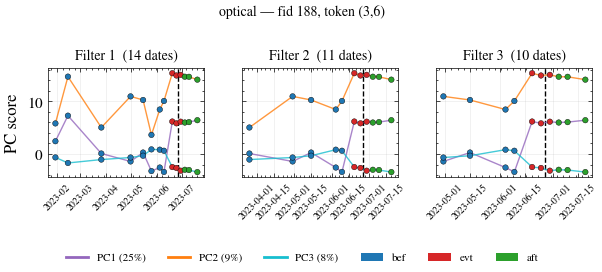

In [21]:
def pca_versions_row(fid, tile, tok_r, tok_c, modality,
                     versions=("v1", "v2", "v3"), nc=3):
    """PC1 to PC3 of one token under each cloud filter, one panel per filter."""
    base = _fit_common_base_pca(fid, tile, modality, nc)
    if base is None:
        print(f"[{modality}] no common-S2 base image")
        return
    pca, evr = base[0], base[0].explained_variance_ratio_
    evt = _event_date(fid)

    fig, axes = plt.subplots(1, len(versions), figsize=(TEXT_W, TEXT_W * 0.38),
                             sharey=True)
    axes = np.atleast_1d(axes)
    for ax, version in zip(axes, versions):
        allowed = _allowed_ids_for_fid(CSV_TEMPLATE.format(version=version), fid)
        paths = _paths_for(fid, tile, modality, allowed["s2"], allowed["s1"])
        if not paths:
            ax.set_title(f"{version}: no data", fontsize=9); ax.axis("off"); continue
        cube = np.stack([np.load(p) for p in paths])
        scores = pca.transform(cube[:, tok_r, tok_c, :])
        dates = pd.to_datetime([_by_date_any(p)[:8] for p in paths])
        colors = [WIN_COLORS[_by_win(p)] for p in paths]
        for k in range(nc):
            ax.plot(dates, scores[:, k], "-", color=PC_COLORS[k], alpha=0.8, lw=1.0)
            ax.scatter(dates, scores[:, k], c=colors, s=16,
                       edgecolors="black", linewidths=0.3, zorder=3)
        if evt is not None:
            ax.axvline(evt, color="black", ls="--", lw=1.0, zorder=0)
        ax.set_title(f"Filter {version[-1]}  ({len(paths)} dates)", fontsize=10)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("PC score")
    handles = [plt.Line2D([0], [0], color=PC_COLORS[k], lw=2,
                          label=f"PC{k+1} ({evr[k]:.0%})") for k in range(nc)]
    handles += [Patch(facecolor=c, label=w) for w, c in WIN_COLORS.items()]
    fig.legend(handles=handles, ncol=6, fontsize=8, loc="lower center",
               bbox_to_anchor=(0.5, -0.14), frameon=False)
    fig.suptitle(f"{modality} — fid {fid}, token ({tok_r},{tok_c})", fontsize=10)
    fig.tight_layout()
    plt.show()


set_prefix(f"rq12_filters_fid{FID}_optical")
pca_versions_row(FID, TILE, TOK_R, TOK_C, "optical")

## Notes

- **The token is frozen** at (3, 6) in the definition cell, so the figures do not depend on
  the seed. Set both to `None` to draw a new one at random.
- **Watch the joint panels.** Under v3 this polygon has two dates in the after window in
  joint mode, against three in optical. With two points after the event the joint
  trajectory supports a weaker claim than the optical one. Say so in the text rather than
  reading it as if it were the same evidence.
- The \acs{PCA} axes are fitted per mode, so PC1 in optical and PC1 in joint are different
  axes: only the shape of the trajectory is comparable between modes, never the values.
- Copy the PDFs to `manuscript_tropical_forest_disturbance/figures/`.